# Training Pipeline: Sovereign Dialect-Bridge


# Setup Env


In [1]:
import os, sys

IN_KAGGLE = os.path.exists('/kaggle/input')
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

ENV = "Kaggle" if IN_KAGGLE else ("Colab" if IN_COLAB else "Lokal")
print(f"Environment: {ENV}")


Environment: Kaggle


In [2]:
import torch

if IN_KAGGLE:
    # SELALU isolasi ke GPU-0, bahkan di T4x2.
    # HuggingFace Trainer di Jupyter (single-process) otomatis pakai DataParallel
    # saat 2 GPU terdeteksi → gradient sync membebani GPU-0 (12+ GB untuk model 580M).
    # Single-GPU lebih efisien dan menghindari deadlock DataParallel + DataLoader workers.
    os.environ["CUDA_VISIBLE_DEVICES"]   = "0"
    os.environ["TOKENIZERS_PARALLELISM"] = "false"
    os.environ["NCCL_P2P_DISABLE"]       = "1"
    os.environ["PYTORCH_ALLOC_CONF"]     = "expandable_segments:True"
    os.environ["CUDA_LAUNCH_BLOCKING"]   = "1"

    num_gpus = torch.cuda.device_count() if torch.cuda.is_available() else 0
    print(f"GPU aktif (setelah isolasi ke GPU-0): {num_gpus}")
    print("Kaggle env variables set.")

GPU aktif (setelah isolasi ke GPU-0): 1
Kaggle env variables set.


In [3]:
if IN_KAGGLE:
    os.system('pip install -q "unsloth[kaggle-new]" --upgrade')
    os.system('pip install -q --no-deps trl peft accelerate bitsandbytes')
elif IN_COLAB:
    os.system('pip install -q "unsloth[colab-new]" --upgrade')
    os.system('pip install -q --no-deps trl peft accelerate bitsandbytes')

os.system('pip install -q datasets rouge-score transformers sumy PySastrawi')
print("Semua package terinstall.")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.8/57.8 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 31.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 30.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 109.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 668.2/668.2 kB 40.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 kB 27.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 869.6/869.6 kB 49.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 93.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 75.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.2/185.2 kB 14.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.1/71.1 MB 27.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.7/119.7 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.35.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
s3fs 2026.2.0 requires fsspec==2026.2.0, but you have fsspec 2025.9.0 which is incompatible.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2025.9.0 which is incompatible.


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.5/73.5 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.2/211.2 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 81.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 109.0 MB/s eta 0:00:00
Semua package terinstall.


# Import Library Conf and CONST Var Hyperparamaeter


In [4]:
import os, re, gc, sys, json, inspect, random
import torch
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from collections import Counter, defaultdict
from rouge_score import rouge_scorer
from transformers import (
    AutoTokenizer, AutoModelForSeq2SeqLM, AutoModelForSequenceClassification,
    Seq2SeqTrainer, Seq2SeqTrainingArguments, DataCollatorForSeq2Seq,
    Trainer, TrainingArguments, DataCollatorWithPadding,
    EarlyStoppingCallback,
    pipeline,
)
from datasets import Dataset as HFDataset
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from sumy.parsers.plaintext import PlaintextParser
from sumy.nlp.tokenizers import Tokenizer as SumyTokenizer
from sumy.summarizers.text_rank import TextRankSummarizer
from nltk.corpus import stopwords
import nltk
nltk.download('punkt',     quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)

# Kompatibilitas transformers: >=4.46 ganti 'tokenizer' -> 'processing_class' di Trainer
_TOK_KWARG = (
    "processing_class"
    if "processing_class" in inspect.signature(Trainer.__init__).parameters
    else "tokenizer"
)

# Cek ketersediaan bitsandbytes untuk adamw_8bit
try:
    import bitsandbytes as _bnb
    _OPTIM = "adamw_8bit"
except ImportError:
    _OPTIM = "adamw_torch"

print(f"Import selesai.")
print(f"Trainer tokenizer kwarg : '{_TOK_KWARG}'")
print(f"Optimizer               : {_OPTIM}")

Skipping import of cpp extensions due to incompatible torch version. Please upgrade to torch >= 2.11.0 (found 2.10.0+cu128).


Import selesai.
Trainer tokenizer kwarg : 'processing_class'
Optimizer               : adamw_8bit


In [5]:
RANDOM_SEED    = 42
TRAIN_SUBSET   = 7000
N_VAL          = 750
N_TEST         = 700
MAX_INPUT_LEN  = 512
MAX_TARGET_LEN = 128
NUM_EPOCHS     = 3
BATCH_SIZE     = 4
GRAD_ACCUM     = 4
LEARNING_RATE  = 3e-4

MT5_MODEL    = 'google/mt5-base'
INDOT5_MODEL = 'cahya/t5-base-indonesian-summarization-cased'
NER_MODEL    = 'cahya/bert-base-indonesian-NER'

random.seed(RANDOM_SEED)
print(f'TRAIN_SUBSET={TRAIN_SUBSET} | N_TEST={N_TEST} | N_EPOCHS={NUM_EPOCHS}')
print(f'LR={LEARNING_RATE} | BATCH={BATCH_SIZE} | GRAD_ACCUM={GRAD_ACCUM}')


TRAIN_SUBSET=7000 | N_TEST=700 | N_EPOCHS=3
LR=0.0003 | BATCH=4 | GRAD_ACCUM=4


In [6]:
# Deteksi perangkat komputasi secara otomatis
if torch.cuda.is_available():
    DEVICE = "cuda"
elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
    DEVICE = "mps"    # Apple Silicon M1/M2/M3
else:
    DEVICE = "cpu"

USE_FP16 = DEVICE == "cuda"   # fp16 hanya tersedia di CUDA
USE_BF16 = DEVICE == "mps"    # bf16 tersedia di Apple Silicon

print(f"Perangkat  : {DEVICE.upper()}")
print(f"Presisi    : fp16={USE_FP16}, bf16={USE_BF16}")
if DEVICE == "mps":
    print("Tip Mac M1 : set TRAIN_SUBSET=1000 dan NUM_EPOCHS=1 agar lebih cepat")
elif DEVICE == "cpu":
    print("Tip CPU    : training mT5 akan sangat lambat, disarankan di GPU")


Perangkat  : CUDA
Presisi    : fp16=True, bf16=False


In [7]:
BASE = '/kaggle/input/datasets/fadhlannurrachman/dataset' if IN_KAGGLE else '../dataset'

INDOSUM_DIR  = Path(BASE) / 'indosum'
NUSAX_MT_DIR = Path(BASE) / 'nusax/datasets/mt'
OUTPUT_DIR   = Path('/kaggle/working') if IN_KAGGLE else Path('..')
MODEL_DIR    = OUTPUT_DIR / 'model'
MODEL_DIR.mkdir(parents=True, exist_ok=True)

MT5_PATH    = str(MODEL_DIR / 'mt5-indosum')
INDOT5_PATH = str(MODEL_DIR / 'indot5-indosum')
NER_PATH    = str(MODEL_DIR / 'ner')

print(f'IndoSum ada  : {INDOSUM_DIR.exists()}')
print(f'NusaX ada    : {NUSAX_MT_DIR.exists()}')
print(f'Model dir    : {MODEL_DIR.resolve()}')


IndoSum ada  : True
NusaX ada    : True
Model dir    : /kaggle/working/model


# Load & Preview Dataset

IndoSum — 19.000+ artikel berita Indonesia dengan ringkasan referensi manusia.
Sumber: [kata-ai/indosum](https://github.com/kata-ai/indosum)

NusaX — 1.000 kalimat paralel dalam 12 bahasa (Jawa, Sunda, Minang, Bali, dll).
Sumber: [IndoNLP/nusa-crowd](https://github.com/IndoNLP/nusa-crowd)


In [8]:
def flatten_tokens(nested):
    """Ubah struktur token bersarang IndoSum menjadi teks biasa."""
    if not nested:
        return ""
    if isinstance(nested[0][0], list):
        # paragraf: list[list[list[str]]]
        sentences = [" ".join(sent) for para in nested for sent in para]
        return ". ".join(sentences)
    # summary: list[list[str]]
    return " ".join(" ".join(sent) for sent in nested)


def load_indosum(data_dir, split, fold=1):
    """Muat satu split IndoSum, kembalikan list of dict {text, summary, category}."""
    path = Path(data_dir) / f"{split}.0{fold}.jsonl"
    records = []
    with open(path, encoding="utf-8") as f:
        for line in f:
            r = json.loads(line)
            records.append({
                "text":     flatten_tokens(r["paragraphs"]),
                "summary":  flatten_tokens(r["summary"]),
                "category": r["category"],
            })
    return records


In [9]:
train_data  = load_indosum(INDOSUM_DIR, "train", fold=1)
val_data    = load_indosum(INDOSUM_DIR, "dev",   fold=1)
test_data   = load_indosum(INDOSUM_DIR, "test",  fold=1)

# Stratified random sampling berdasarkan kategori — lebih representatif dari [:N_TEST]
random.seed(RANDOM_SEED)
_cat_buckets = defaultdict(list)
for r in test_data:
    _cat_buckets[r["category"]].append(r)

_per_cat = N_TEST // len(_cat_buckets)
test_subset = []
for _cat, _recs in sorted(_cat_buckets.items()):
    _n = min(_per_cat, len(_recs))
    test_subset.extend(random.sample(_recs, _n))

# Tambah sampel acak dari sisa jika kurang dari N_TEST
_used_ids = set(id(r) for r in test_subset)
_remaining = [r for r in test_data if id(r) not in _used_ids]
_need = N_TEST - len(test_subset)
if _need > 0 and _remaining:
    test_subset.extend(random.sample(_remaining, min(_need, len(_remaining))))
random.shuffle(test_subset)

def avg_words(records, key):
    return sum(len(r[key].split()) for r in records) / len(records)

print(f"{'Split':<8} {'N':>6} {'Avg Teks (kata)':>18} {'Avg Ringkasan (kata)':>22}")
print("-" * 58)
for name, data in [("train", train_data), ("dev", val_data), ("test", test_data)]:
    print(f"{name:<8} {len(data):>6} {avg_words(data, 'text'):>18.1f} {avg_words(data, 'summary'):>22.1f}")
print()
print(f"Test subset (stratified): {len(test_subset)} sampel")
_dist = Counter(r["category"] for r in test_subset)
for _c, _n in sorted(_dist.items()):
    print(f"  {_c}: {_n}")

Split         N    Avg Teks (kata)   Avg Ringkasan (kata)
----------------------------------------------------------
train     14262              346.8                   67.7
dev         750              348.6                   67.7
test       3762              343.3                   67.7

Test subset (stratified): 700 sampel
  hiburan: 122
  inspirasi: 29
  olahraga: 149
  showbiz: 124
  tajuk utama: 149
  teknologi: 127


In [10]:
# Preview 3 sampel dari IndoSum
print("=" * 70)
print("Contoh Data IndoSum")
print("=" * 70)
for i, r in enumerate(train_data[:3]):
    print()
    print(f"[Sampel {i+1}] Kategori: {r['category']}")
    print(f"  Teks     : {r['text'][:200]}...")
    print(f"  Ringkasan: {r['summary'][:120]}...")

Contoh Data IndoSum

[Sampel 1] Kategori: tajuk utama
  Teks     : Jakarta , CNN Indonesia - - Dokter Ryan Thamrin , yang terkenal lewat acara Dokter Oz Indonesia , meninggal dunia pada Jumat ( 4 / 8 ) dini hari .. Dokter Lula Kamal yang merupakan selebriti sekaligus...
  Ringkasan: Dokter Lula Kamal yang merupakan selebriti sekaligus rekan kerja Ryan Thamrin menyebut kawannya itu sudah sakit sejak se...

[Sampel 2] Kategori: teknologi
  Teks     : Selfie ialah salah satu tema terpanas di kalangan produsen smartphone , bahkan menjadi senjata andalan beberapa brand terkenal .. Anda mungkin berpikir bahwa saat ini , pasar handset spesialis selfie ...
  Ringkasan: Asus memperkenalkan   ZenFone generasi keempat dan keduanya sama-sama dibekali setup kamera ganda di depan . Mereka adal...

[Sampel 3] Kategori: hiburan
  Teks     : Jakarta , CNN Indonesia - - Dinas Pariwisata Provinsi Bengkulu kembali menggelar kegiatan Bimbingan Teknis ( Bimtek ) SDM Kepariwisataan dalam menyongson " Visit 2

In [11]:
# Load NusaX Machine Translation dataset (kalimat paralel antar dialek)
mt_all = pd.concat([
    pd.read_csv(NUSAX_MT_DIR / "train.csv"),
    pd.read_csv(NUSAX_MT_DIR / "valid.csv"),
    pd.read_csv(NUSAX_MT_DIR / "test.csv"),
], ignore_index=True)

DIALECT_COLS = [
    "javanese", "sundanese", "minangkabau", "balinese",
    "banjarese", "buginese", "madurese", "acehnese", "ngaju", "toba_batak",
]

print(f"NusaX MT: {len(mt_all)} kalimat paralel, {len(DIALECT_COLS)} dialek")
print()
print("Contoh kalimat paralel — 3 dialek vs Bahasa Indonesia:")
print("=" * 70)
idx = 0
print(f"  {'Indonesia':<14}: {str(mt_all['indonesian'].iloc[idx])[:80]}")
for d in ["javanese", "sundanese", "minangkabau"]:
    val = mt_all[d].iloc[idx]
    print(f"  {d.capitalize():<14}: {str(val)[:80]}")


NusaX MT: 1000 kalimat paralel, 10 dialek

Contoh kalimat paralel — 3 dialek vs Bahasa Indonesia:
  Indonesia     : Nikmati cicilan 0% hingga 12 bulan untuk pemesanan tiket pesawat air asia dengan
  Javanese      : Nikmatono cicilan 0% sampek 12 sasi dinggo pesen tiket kapal air asia nganggo ke
  Sundanese     : Nikmati angsuran 0% dugi ka 12 bulan kanggo mesen tiket pasawat air asia nganggo
  Minangkabau   : Nikmati cicilan 0% sampai 12 bulan untuak pamasanan tiket pisawat air asia jo ka


## Section 3: EDA Singkat

Eksplorasi awal untuk memahami karakteristik dataset.
EDA lengkap (analisis kosakata per dialek, lexicon, distribusi detail) tersedia di `eda.ipynb`.


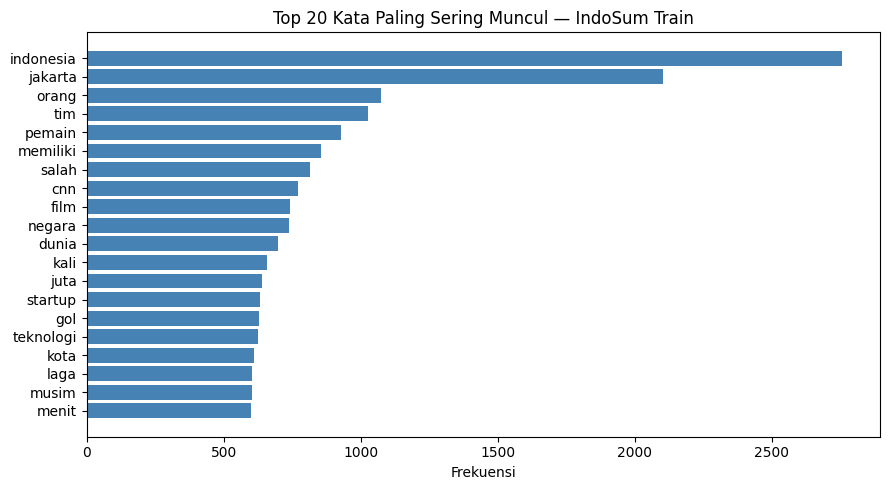

In [12]:
# Grafik 1: Top 20 kata paling sering muncul (exclude stopwords)
id_stopwords = set(stopwords.words("indonesian"))
all_text = " ".join(r["text"] for r in train_data[:2000])  # sampel 2000 agar cepat
tokens   = [
    w.lower() for w in all_text.split()
    if w.isalpha() and w.lower() not in id_stopwords and len(w) > 2
]
top20 = Counter(tokens).most_common(20)
words, counts = zip(*top20)

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(list(reversed(words)), list(reversed(counts)), color="steelblue")
ax.set_title("Top 20 Kata Paling Sering Muncul — IndoSum Train")
ax.set_xlabel("Frekuensi")
plt.tight_layout()
plt.show()


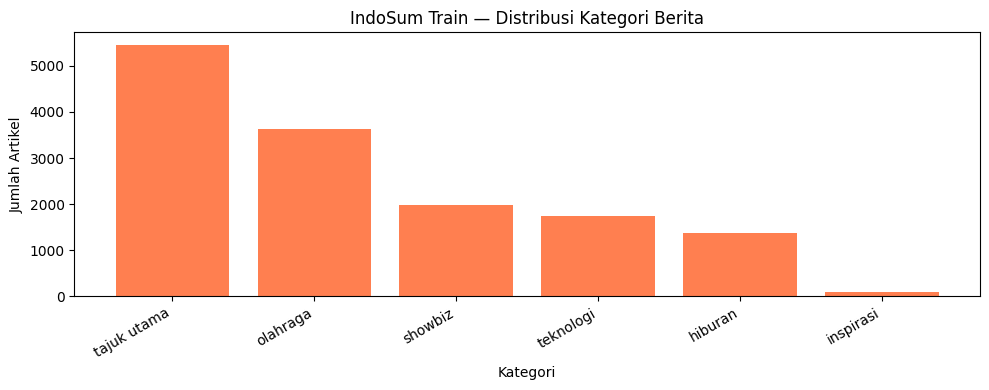

In [13]:
# Grafik 2: Distribusi kategori berita IndoSum
cats = Counter(r["category"] for r in train_data)
cats_sorted = dict(sorted(cats.items(), key=lambda x: -x[1]))

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(cats_sorted.keys(), cats_sorted.values(), color="coral")
ax.set_title("IndoSum Train — Distribusi Kategori Berita")
ax.set_ylabel("Jumlah Artikel")
ax.set_xlabel("Kategori")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


In [14]:
# Statistik ringkasan dataset
text_lens = [len(r["text"].split())    for r in train_data]
sum_lens  = [len(r["summary"].split()) for r in train_data]
ratios    = [s / t for t, s in zip(text_lens, sum_lens) if t > 0]

print("Statistik IndoSum Train:")
print(f"  Panjang rata-rata artikel   : {sum(text_lens)/len(text_lens):.0f} kata")
print(f"  Panjang rata-rata ringkasan : {sum(sum_lens)/len(sum_lens):.0f} kata")
print(f"  Compression ratio rata-rata : {sum(ratios)/len(ratios):.3f}")
print(f"  Artinya: ringkasan ~{sum(ratios)/len(ratios)*100:.0f}% dari panjang artikel")
print()
print("Statistik NusaX MT:")
print(f"  Total kalimat paralel : {len(mt_all)}")
print(f"  Jumlah dialek         : {len(DIALECT_COLS)}")
print(f"  Dialek tersedia       : {', '.join(DIALECT_COLS)}")


Statistik IndoSum Train:
  Panjang rata-rata artikel   : 347 kata
  Panjang rata-rata ringkasan : 68 kata
  Compression ratio rata-rata : 0.225
  Artinya: ringkasan ~23% dari panjang artikel

Statistik NusaX MT:
  Total kalimat paralel : 1000
  Jumlah dialek         : 10
  Dialek tersedia       : javanese, sundanese, minangkabau, balinese, banjarese, buginese, madurese, acehnese, ngaju, toba_batak


## Section 4: Text Preprocessing

Pipeline preprocessing untuk summarization dialek Indonesia:

- Clean Noise
- Correct Dialect Slang
- Normalize
- Yg Gak Dilakuin : Stemming (sastrawi), Stopwords, remove numbering

In [15]:

_stemmer = StemmerFactory().create_stemmer()

# Kata-kata yang tidak boleh di-stem (singkatan, nama dinas, dll)
STEM_STOPWORDS = {
    "rt", "rw", "jl", "bpbd", "dinas", "kelurahan", "kecamatan",
    "lapor", "laporan", "pengaduan", "warga", "masyarakat",
}

# Kamus koreksi kata dialek ke Bahasa Indonesia standar
DIALECT_SLANG_DICT = {
    # Jawa
    "mboten": "tidak", "kulo": "saya", "wonten": "ada", "sampun": "sudah",
    "teng": "di", "ngajeng": "depan", "griya": "rumah", "tigang": "tiga",
    "wulan": "bulan", "sanget": "sekali", "nggih": "ya", "mangke": "nanti",
    "panjenengan": "anda", "lare": "anak", "dalan": "jalan", "omah": "rumah",
    "ndandosi": "memperbaiki", "menawi": "kalau",
    # Sunda
    "naha": "kenapa", "punten": "permisi", "mun": "kalau", "keur": "sedang",
    "deui": "lagi", "wae": "saja", "teu": "tidak", "ieu": "ini",
    "eta": "itu", "abdi": "saya", "urang": "kita", "atuh": "dong",
    "mah": "sih", "enya": "iya", "hoyong": "ingin",
    # Minang
    "ambo": "saya", "indak": "tidak", "den": "saya", "awak": "kita",
    "apak": "bapak", "uda": "kakak", "alah": "sudah", "dek": "adik",
    "ndak": "tidak", "beko": "nanti", "ado": "ada", "kampuang": "kampung",
    # Betawi
    "kagak": "tidak", "aye": "saya", "gue": "saya",
    "nyang": "yang", "ente": "kamu", "babe": "bapak",
    "emang": "memang", "udah": "sudah",
    # Bali
    "tiang": "saya", "nenten": "tidak", "mangkin": "sekarang",
    "dumun": "dulu", "sampunang": "jangan",
    # Banjar
    "ulun": "saya", "pian": "kamu", "kada": "tidak", "banar": "benar",
    "handak": "mau",
    # Batak
    "au": "saya", "ndang": "tidak", "nunga": "sudah", "dohot": "dan",
    # Bugis
    "engka": "ada", "degaga": "tidak ada", "matu": "sudah",
    # Melayu
    "tak": "tidak", "dah": "sudah", "nak": "mau",
    # Aceh
    "lon": "saya", "hana": "tidak ada", "nyan": "itu", "nyoe": "ini",
    # Madura
    "sengko": "saya", "arapa": "kenapa",
}

# Compile regex sekali agar efisien saat dipakai berulang
_SLANG_RE = re.compile(
    r"\b(" + "|".join(re.escape(k) for k in DIALECT_SLANG_DICT) + r")\b",
    flags=re.IGNORECASE,
)

print(f"Stemmer PySastrawi : siap")
print(f"Kamus dialek       : {len(DIALECT_SLANG_DICT)} entri dari 10 dialek")


Stemmer PySastrawi : siap
Kamus dialek       : 79 entri dari 10 dialek


In [16]:

def clean_noise(text):
    """Langkah 1: Hapus URL, karakter noise, dan whitespace berlebih."""
    text = re.sub(r"https?://\S+|www\.\S+", "", text)
    text = re.sub(r"[^\x00-\x7FÀ-ɏḀ-ỿ]", " ", text)
    text = re.sub(r"(.)\1{3,}", r"\1\1", text)     # karakter berulang lebih dari 3x
    text = re.sub(r"[\r\n\t]+", " ", text)
    text = re.sub(r" {2,}", " ", text)
    return text.strip()

# Demo
sample = "Jalan rusaaakkk!!! Cek https://maps.google.com   untuk detailnya."
print("Sebelum:", sample)
print("Sesudah:", clean_noise(sample))


Sebelum: Jalan rusaaakkk!!! Cek https://maps.google.com   untuk detailnya.
Sesudah: Jalan rusaaakkk!!! Cek untuk detailnya.


In [17]:

def correct_dialect_slang(text):
    """Langkah 2: Koreksi kata dialek ke Bahasa Indonesia standar."""
    return _SLANG_RE.sub(
        lambda m: DIALECT_SLANG_DICT.get(m.group(0).lower(), m.group(0)),
        text,
    )

# Demo
sample = "Kulo mboten mangertos kenapa jalan teng ngajeng griya sampun rusak."
print("Sebelum:", sample)
print("Sesudah:", correct_dialect_slang(sample))


Sebelum: Kulo mboten mangertos kenapa jalan teng ngajeng griya sampun rusak.
Sesudah: saya tidak mangertos kenapa jalan di depan rumah sudah rusak.


In [18]:

def normalize_case_punct(text):
    """Langkah 3: Lowercase dan normalisasi tanda baca berlebih."""
    text = text.lower()
    text = re.sub(r"[!?]{2,}", "!", text) # ??? -> !
    text = re.sub(r"\.{2,}", "...", text) # .... -> ...
    text = re.sub(r"\s([.,!?;:])", r"\1", text)
    text = re.sub(r" {2,}", " ", text)
    return text.strip()

# Demo
sample = "Jalan RUSAK PARAH !!! sudah 3 bulan ..."
print("Sebelum:", sample)
print("Sesudah:", normalize_case_punct(sample))


Sebelum: Jalan RUSAK PARAH !!! sudah 3 bulan ...
Sesudah: jalan rusak parah! sudah 3 bulan...


In [19]:
# Demonstrasi mengapa Sastrawi TIDAK digunakan dalam pipeline ini
# (ditampilkan sebagai referensi/perbandingan saja)
def stem_text(text):
    """Demonstrasi: Sastrawi ECS stemmer — TIDAK dipakai dalam pipeline."""
    tokens = text.split()
    return " ".join(
        tok if tok in STEM_STOPWORDS else _stemmer.stem(tok)
        for tok in tokens
    )

# Bukti bahwa stemming merusak makna untuk domain summarization
samples = [
    "pemerintah sedang memperbaiki jalan yang rusak di daerah tersebut",
    "pengaduan warga mengenai infrastruktur yang memprihatinkan",
]
print("DEMO: Sastrawi over-stemming (ini yang DIHINDARI dalam pipeline):")
for s in samples:
    print(f"  Sebelum: {s}")
    print(f"  Sesudah: {stem_text(s)}")
    print()

DEMO: Sastrawi over-stemming (ini yang DIHINDARI dalam pipeline):
  Sebelum: pemerintah sedang memperbaiki jalan yang rusak di daerah tersebut
  Sesudah: perintah sedang baik jalan yang rusak di daerah sebut

  Sebelum: pengaduan warga mengenai infrastruktur yang memprihatinkan
  Sesudah: pengaduan warga kena infrastruktur yang prihatin



In [20]:
def preprocess_extractive(text, apply_dialect=False):
    """Preprocessing untuk metode EKSTRAKTIF (TextRank, NER): tanpa stemming.

    Sastrawi dirancang untuk Information Retrieval, bukan summarization.
    Stemming agresif merusak makna: "pemerintah"→"perintah", "memperbaiki"→"baik".
    """
    text = clean_noise(text)
    if apply_dialect:
        text = correct_dialect_slang(text)
    text = normalize_case_punct(text)
    return text


def preprocess_abstractive(text, apply_dialect=False):
    """Preprocessing untuk metode ABSTRAKTIF (mT5, IndoBART, IndoT5): tanpa stemming."""
    text = clean_noise(text)
    if apply_dialect:
        text = correct_dialect_slang(text)
    text = normalize_case_punct(text)
    return text


# Demo: preprocessing pada teks dialek Jawa
teks_jawa = "pak, jalan teng ngajeng griya kulo rusak parah. sampun tigang wulan mboten wonten ingkang memperbaiki!"
print("Input (Jawa):")
print(teks_jawa)
print()
print("preprocess_extractive (TextRank/NER, apply_dialect=True):")
print(preprocess_extractive(teks_jawa, apply_dialect=True))
print()
print("preprocess_abstractive (mT5/IndoBART/IndoT5, apply_dialect=True):")
print(preprocess_abstractive(teks_jawa, apply_dialect=True))
print()
print("Mengapa Sastrawi tidak cocok untuk summarization:")
for s in ["pemerintah sedang memperbaiki jalan", "tersebut", "pengaduan warga"]:
    stemmed = " ".join(_stemmer.stem(w) for w in s.split())
    print(f"  '{s}'  →  '{stemmed}'")


Input (Jawa):
pak, jalan teng ngajeng griya kulo rusak parah. sampun tigang wulan mboten wonten ingkang memperbaiki!

preprocess_extractive (TextRank/NER, apply_dialect=True):
pak, jalan di depan rumah saya rusak parah. sudah tiga bulan tidak ada ingkang memperbaiki!

preprocess_abstractive (mT5/IndoBART/IndoT5, apply_dialect=True):
pak, jalan di depan rumah saya rusak parah. sudah tiga bulan tidak ada ingkang memperbaiki!

Mengapa Sastrawi tidak cocok untuk summarization:
  'pemerintah sedang memperbaiki jalan'  →  'perintah sedang baik jalan'
  'tersebut'  →  'sebut'
  'pengaduan warga'  →  'adu warga'


# Method — IndoT5 Fine-tuning

IndoT5 Modle Checkpoint :  (`cahya/t5-base-indonesian-summarization-cased`)

In [21]:
# Load IndoT5 tokenizer — model domain-specific, gunakan AutoTokenizer dengan fallback T5Tokenizer
try:
    indot5_tokenizer = AutoTokenizer.from_pretrained(INDOT5_MODEL)
    print(f"IndoT5 tokenizer loaded via AutoTokenizer")
except Exception as _e1:
    try:
        from transformers import T5Tokenizer
        indot5_tokenizer = T5Tokenizer.from_pretrained(INDOT5_MODEL)
        print(f"IndoT5 tokenizer loaded via T5Tokenizer")
    except Exception as _e2:
        raise RuntimeError(f"Tidak bisa load IndoT5 tokenizer: {_e2}")

def preprocess_indot5(examples):
    """Tokenisasi untuk IndoT5 — tanpa prefix khusus (model sudah fine-tuned for summarization)."""
    model_inputs = indot5_tokenizer(
        examples["text"], max_length=MAX_INPUT_LEN, truncation=True, padding=False,
    )
    labels = indot5_tokenizer(
        text_target=examples["summary"],
        max_length=MAX_TARGET_LEN, truncation=True, padding=False,
    )
    _pad = indot5_tokenizer.pad_token_id
    model_inputs["labels"] = [
        [tok if tok != _pad else -100 for tok in seq]
        for seq in labels["input_ids"]
    ]
    return model_inputs

# Siapkan dataset
train_hf_it  = HFDataset.from_list(train_data[:TRAIN_SUBSET])
val_hf_it    = HFDataset.from_list(val_data[:N_VAL])
train_tok_it = train_hf_it.map(preprocess_indot5, batched=True, remove_columns=train_hf_it.column_names)
val_tok_it   = val_hf_it.map(preprocess_indot5,   batched=True, remove_columns=val_hf_it.column_names)

print(f"IndoT5 model   : {INDOT5_MODEL}")
print(f"pad_token_id   : {indot5_tokenizer.pad_token_id}")
print(f"Train tokenized: {len(train_tok_it)} | Val tokenized: {len(val_tok_it)}")

config.json:   0%|          | 0.00/657 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.07k [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/793k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/1.79k [00:00<?, ?B/s]

IndoT5 tokenizer loaded via AutoTokenizer


Map:   0%|          | 0/7000 [00:00<?, ? examples/s]

Map:   0%|          | 0/750 [00:00<?, ? examples/s]

IndoT5 model   : cahya/t5-base-indonesian-summarization-cased
pad_token_id   : 0
Train tokenized: 7000 | Val tokenized: 750


In [22]:
indot5_model = AutoModelForSeq2SeqLM.from_pretrained(INDOT5_MODEL)

it_collator = DataCollatorForSeq2Seq(
    indot5_tokenizer, model=indot5_model, padding=True, label_pad_token_id=-100,
)

_n_gpu_it  = torch.cuda.device_count() if DEVICE == "cuda" else 1
_steps_it  = max(1, TRAIN_SUBSET // (BATCH_SIZE * _n_gpu_it * GRAD_ACCUM))
_warmup_it = max(50, _steps_it // 5)

print(f"GPU: {_n_gpu_it} | Warmup steps: {_warmup_it}")
if DEVICE == "cuda":
    _free, _tot = torch.cuda.mem_get_info()
    print(f"VRAM tersedia: {_free/1024**3:.1f} GB / {_tot/1024**3:.1f} GB")

it_args = Seq2SeqTrainingArguments(
    output_dir=INDOT5_PATH,
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=2,
    gradient_accumulation_steps=GRAD_ACCUM,
    learning_rate=LEARNING_RATE,
    warmup_steps=_warmup_it,
    weight_decay=0.01,
    optim=_OPTIM,
    label_smoothing_factor=0.0,
    fp16=USE_FP16,
    bf16=USE_BF16,
    gradient_checkpointing=True,
    predict_with_generate=True,
    generation_max_length=MAX_TARGET_LEN,
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=1,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    logging_steps=50,
    report_to="none",
    seed=RANDOM_SEED,
    dataloader_num_workers=2,
    dataloader_pin_memory=False,
    eval_accumulation_steps=8,
    ddp_find_unused_parameters=False,
)

INDOT5_TRAINED = False
try:
    it_trainer = Seq2SeqTrainer(
        model=indot5_model,
        args=it_args,
        train_dataset=train_tok_it,
        eval_dataset=val_tok_it,
        data_collator=it_collator,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=1)],
        **{_TOK_KWARG: indot5_tokenizer},
    )
    print(f"\nMulai training IndoT5 ({TRAIN_SUBSET} data, {NUM_EPOCHS} epoch, device={DEVICE})...")
    it_trainer.train()
    it_trainer.save_model(INDOT5_PATH)
    indot5_tokenizer.save_pretrained(INDOT5_PATH)
    INDOT5_TRAINED = True
    print(f"Training selesai. Model disimpan di: {INDOT5_PATH}")
except Exception as _e:
    print(f"\n[WARNING] IndoT5 training gagal: {type(_e).__name__}: {_e}")
    INDOT5_TRAINED = False
    gc.collect()
    if DEVICE == "cuda":
        torch.cuda.empty_cache()

pytorch_model.bin:   0%|          | 0.00/892M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/892M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/260 [00:00<?, ?it/s]

GPU: 1 | Warmup steps: 87
VRAM tersedia: 14.5 GB / 14.6 GB

Mulai training IndoT5 (7000 data, 3 epoch, device=cuda)...


Epoch,Training Loss,Validation Loss
1,2.238998,0.503061
2,1.589987,0.516441


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['encoder.embed_tokens.weight', 'decoder.embed_tokens.weight', 'lm_head.weight'].


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training selesai. Model disimpan di: /kaggle/working/model/indot5-indosum


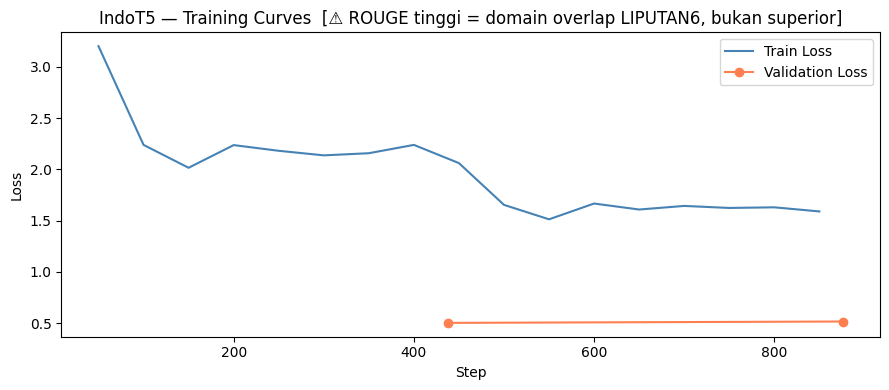

Final train loss : 1.5900
Best val loss    : 0.5031


In [23]:
# Plot training curves IndoT5
if INDOT5_TRAINED:
    _log_it       = it_trainer.state.log_history
    _tr_steps_it  = [x["step"]      for x in _log_it if "loss"      in x and "eval_loss" not in x]
    _tr_losses_it = [x["loss"]      for x in _log_it if "loss"      in x and "eval_loss" not in x]
    _val_steps_it = [x["step"]      for x in _log_it if "eval_loss" in x]
    _val_loss_it  = [x["eval_loss"] for x in _log_it if "eval_loss" in x]

    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(_tr_steps_it,  _tr_losses_it, label="Train Loss",      color="steelblue")
    ax.plot(_val_steps_it, _val_loss_it,  label="Validation Loss", color="coral", marker="o")
    ax.set_title("IndoT5 — Training Curves")
    ax.set_xlabel("Step")
    ax.set_ylabel("Loss")
    ax.legend()
    plt.tight_layout()
    plt.show()
    print(f"Final train loss : {_tr_losses_it[-1]:.4f}" if _tr_losses_it else "")
    print(f"Best val loss    : {min(_val_loss_it):.4f}"  if _val_loss_it  else "")
else:
    print("[INFO] IndoT5 tidak dilatih — training curves tidak tersedia.")

In [24]:
if INDOT5_TRAINED:
    indot5_model.eval()
    if DEVICE != "cpu":
        indot5_model = indot5_model.to(DEVICE)

    print(f"Menghasilkan prediksi IndoT5 pada {N_TEST} sampel...")
    indot5_preds = []
    for i, record in enumerate(test_subset):
        inputs = indot5_tokenizer(
            record["text"], return_tensors="pt",
            max_length=MAX_INPUT_LEN, truncation=True,
        )
        if DEVICE != "cpu":
            inputs = {k: v.to(DEVICE) for k, v in inputs.items()}
        with torch.no_grad():
            out = indot5_model.generate(
                **inputs, max_new_tokens=MAX_TARGET_LEN, num_beams=4,
                no_repeat_ngram_size=3,
            )
        indot5_preds.append(indot5_tokenizer.decode(out[0], skip_special_tokens=True).strip())
        if (i + 1) % 50 == 0:
            print(f"  {i + 1}/{N_TEST} selesai")
    print("Selesai. Contoh:", indot5_preds[0][:150])
else:
    indot5_preds = [""] * N_TEST
    print("[INFO] IndoT5 training gagal — prediksi diisi string kosong.")

Menghasilkan prediksi IndoT5 pada 700 sampel...
  50/700 selesai
  100/700 selesai
  150/700 selesai
  200/700 selesai
  250/700 selesai
  300/700 selesai
  350/700 selesai
  400/700 selesai
  450/700 selesai
  500/700 selesai
  550/700 selesai
  600/700 selesai
  650/700 selesai
  700/700 selesai
Selesai. Contoh: AS Roma berhasil mencuri tiga angka dari kandang Udinese dalam lanjutan Serie A Liga Italia , Sabtu 917 / 2 / 2018 . Kemenangan ini tentu sangat berar


In [25]:
# Bersihkan GPU memory sebelum section berikutnya
for _var in ["indot5_model", "it_trainer", "train_hf_it", "train_tok_it", "val_hf_it", "val_tok_it"]:
    try:
        del globals()[_var]
    except KeyError:
        pass
gc.collect()
if DEVICE == "cuda":
    torch.cuda.empty_cache()
print("Memory GPU dibersihkan.")

Memory GPU dibersihkan.


## Section 6: Method 1 — mT5-base Fine-tuning (Abstractive)

mT5 (multilingual T5) adalah model encoder-decoder yang sudah dilatih pada 101 bahasa
termasuk Bahasa Indonesia. Dengan fine-tuning pada IndoSum, model belajar menghasilkan
ringkasan **abstraktif** — kalimat baru yang tidak harus ada di teks asli.

Menggunakan **mT5-base** (580M parameter) — lebih besar dari mT5-small (300M),
menghasilkan ringkasan yang lebih koheren dan natural.

**Catatan preprocessing:** Input mT5 menggunakan `preprocess_abstractive()` — **TANPA stemming**.
mT5 tidak pernah dilatih pada teks yang di-stem; stemming akan merusak performa secara signifikan.

**Estimasi waktu training (TRAIN_SUBSET=5000, 3 epoch):**

| Platform | Estimasi |
|----------|----------|
| Kaggle T4 (GPU) | ~90–150 menit |
| Mac M1 Air (MPS) | ~120–200 menit |
| Mac M1 Air (CPU) | ~6–10 jam |

In [26]:
mt5_tokenizer = AutoTokenizer.from_pretrained(MT5_MODEL)

def preprocess_mt5(examples):
    """Tokenisasi untuk mT5 — input 'summarize: <teks>', label harus replace pad→-100."""
    inputs  = ["summarize: " + t for t in examples["text"]]
    model_inputs = mt5_tokenizer(
        inputs, max_length=MAX_INPUT_LEN, truncation=True, padding=False,
    )
    labels = mt5_tokenizer(
        text_target=examples["summary"],
        max_length=MAX_TARGET_LEN, truncation=True, padding=False,
    )
    # PENTING: ganti pad token ID dengan -100 agar cross-entropy tidak menghitung padding
    # Tanpa ini, loss bisa collapse ke 0.0 atau NaN karena loss dihitung atas semua token
    _pad = mt5_tokenizer.pad_token_id
    model_inputs["labels"] = [
        [tok if tok != _pad else -100 for tok in seq]
        for seq in labels["input_ids"]
    ]
    return model_inputs

print(f"mT5 tokenizer dimuat  : {MT5_MODEL}")
print(f"pad_token_id          : {mt5_tokenizer.pad_token_id}")
print(f"decoder_start_token_id: {mt5_tokenizer.pad_token_id}  (= pad, standard untuk mT5)")

# Sanity check tokenisasi
_s = preprocess_mt5({"text": [train_data[0]["text"]], "summary": [train_data[0]["summary"]]})
_n_lbl = sum(1 for t in _s["labels"][0] if t != -100)
print(f"\nSanity check sampel 0:")
print(f"  input_ids  : {len(_s['input_ids'][0])} tokens")
print(f"  label tokens (non-masked): {_n_lbl}")

config.json:   0%|          | 0.00/702 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/376 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/4.31M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/65.0 [00:00<?, ?B/s]

mT5 tokenizer dimuat  : google/mt5-base
pad_token_id          : 0
decoder_start_token_id: 0  (= pad, standard untuk mT5)

Sanity check sampel 0:
  input_ids  : 512 tokens
  label tokens (non-masked): 104


In [27]:
# Siapkan dataset
train_hf = HFDataset.from_list(train_data[:TRAIN_SUBSET])
val_hf   = HFDataset.from_list(val_data[:N_VAL])
train_tok = train_hf.map(preprocess_mt5, batched=True, remove_columns=train_hf.column_names)
val_tok   = val_hf.map(preprocess_mt5,   batched=True, remove_columns=val_hf.column_names)
print(f"Train tokenized: {len(train_tok)} | Val tokenized: {len(val_tok)}")

# Load model
mt5_model = AutoModelForSeq2SeqLM.from_pretrained(MT5_MODEL)
mt5_model.config.tie_word_embeddings = False  # silence tied-weight mismatch warning

# DataCollator: label_pad_token_id=-100 mencegah padding token masuk ke loss
data_collator = DataCollatorForSeq2Seq(
    mt5_tokenizer, model=mt5_model, padding=True, label_pad_token_id=-100,
)

_n_gpu     = torch.cuda.device_count() if DEVICE == "cuda" else 1
_eff_batch = BATCH_SIZE * _n_gpu * GRAD_ACCUM
_steps_ep  = max(1, TRAIN_SUBSET // (BATCH_SIZE * _n_gpu * GRAD_ACCUM))
_warmup    = max(50, _steps_ep // 5)    # ~20% epoch pertama

print(f"GPU: {_n_gpu} | Effective batch: {_eff_batch} | Warmup steps: {_warmup}")
if DEVICE == "cuda":
    _free, _tot = torch.cuda.mem_get_info()
    print(f"VRAM tersedia: {_free/1024**3:.1f} GB / {_tot/1024**3:.1f} GB")

mt5_args = Seq2SeqTrainingArguments(
    output_dir=MT5_PATH,
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=2,
    gradient_accumulation_steps=GRAD_ACCUM,
    learning_rate=LEARNING_RATE,
    warmup_steps=_warmup,               # gunakan steps — warmup_ratio deprecated di v5.2
    weight_decay=0.01,
    optim=_OPTIM,
    # KRITIS: label_smoothing + fp16 menyebabkan NaN validation loss (overflow fp16)
    # Selalu gunakan 0.0 untuk seq2seq dengan fp16
    label_smoothing_factor=0.0,
    fp16=USE_FP16,
    bf16=USE_BF16,
    gradient_checkpointing=True,
    predict_with_generate=True,
    generation_max_length=MAX_TARGET_LEN,
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=1,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    logging_steps=50,
    report_to="none",
    seed=RANDOM_SEED,
    dataloader_num_workers=2,
    dataloader_pin_memory=False,
    eval_accumulation_steps=8,
    ddp_find_unused_parameters=False,
)

mt5_trainer = Seq2SeqTrainer(
    model=mt5_model,
    args=mt5_args,
    train_dataset=train_tok,
    eval_dataset=val_tok,
    data_collator=data_collator,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=1)],
    **{_TOK_KWARG: mt5_tokenizer},
)

print(f"\nMulai training mT5 ({TRAIN_SUBSET} data, {NUM_EPOCHS} epoch, device={DEVICE})...")
mt5_trainer.train()
mt5_trainer.save_model(MT5_PATH)
mt5_tokenizer.save_pretrained(MT5_PATH)
print(f"Training selesai. Model disimpan di: {MT5_PATH}")

Map:   0%|          | 0/7000 [00:00<?, ? examples/s]

Map:   0%|          | 0/750 [00:00<?, ? examples/s]

Train tokenized: 7000 | Val tokenized: 750


pytorch_model.bin:   0%|          | 0.00/2.33G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.33G [00:00<?, ?B/s]

...

Epoch,Training Loss,Validation Loss
1,0.000000,nan
2,0.000000,nan


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training selesai. Model disimpan di: /kaggle/working/model/mt5-indosum


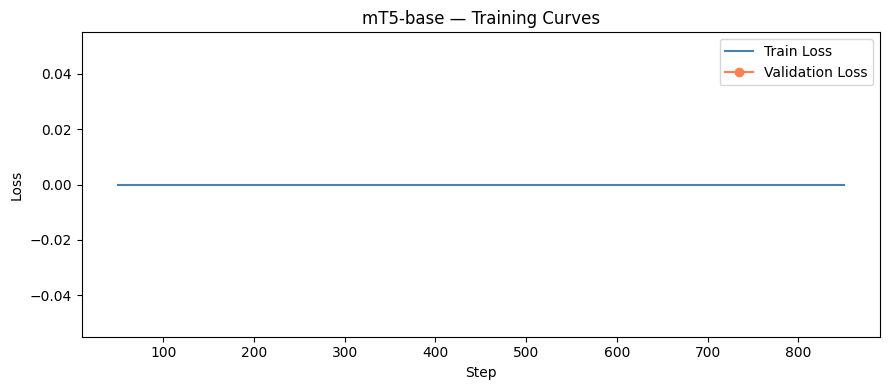

Final train loss : 0.0000
Best val loss    : nan


In [28]:
# Plot training curves mT5
_log          = mt5_trainer.state.log_history
_tr_steps     = [x["step"]      for x in _log if "loss"      in x and "eval_loss" not in x]
_tr_losses    = [x["loss"]      for x in _log if "loss"      in x and "eval_loss" not in x]
_val_steps    = [x["step"]      for x in _log if "eval_loss" in x]
_val_losses   = [x["eval_loss"] for x in _log if "eval_loss" in x]

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(_tr_steps,  _tr_losses,  label="Train Loss",      color="steelblue")
ax.plot(_val_steps, _val_losses, label="Validation Loss", color="coral", marker="o")
ax.set_title("mT5-base — Training Curves")
ax.set_xlabel("Step")
ax.set_ylabel("Loss")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Final train loss : {_tr_losses[-1]:.4f}" if _tr_losses else "")
print(f"Best val loss    : {min(_val_losses):.4f}" if _val_losses else "")

In [29]:
# Generate prediksi mT5 pada subset evaluasi
# CATATAN: mT5 harus generate mulai dari pad token (bukan extra_id_0)
# Jika tidak di-set eksplisit, model bisa generate sentinel tokens
mt5_model.eval()
if DEVICE != "cpu":
    mt5_model = mt5_model.to(DEVICE)

print(f"Menghasilkan prediksi mT5 pada {N_TEST} sampel...")
mt5_preds = []
for i, record in enumerate(test_subset):
    inputs = mt5_tokenizer(
        "summarize: " + record["text"],
        return_tensors="pt", max_length=MAX_INPUT_LEN, truncation=True,
    )
    if DEVICE != "cpu":
        inputs = {k: v.to(DEVICE) for k, v in inputs.items()}
    with torch.no_grad():
        out = mt5_model.generate(
            **inputs,
            max_new_tokens=MAX_TARGET_LEN,
            num_beams=4,
            no_repeat_ngram_size=3,          # hindari repetisi
            decoder_start_token_id=mt5_tokenizer.pad_token_id,  # FIX: jangan pakai extra_id_0
        )
    pred = mt5_tokenizer.decode(out[0], skip_special_tokens=True)
    mt5_preds.append(pred)
    if (i + 1) % 50 == 0:
        print(f"  {i + 1}/{N_TEST} selesai")

print("Selesai.")
# Tampilkan 2 contoh untuk verifikasi tidak ada <extra_id_0>
for i in range(2):
    print(f"\n[Sampel {i+1}] {mt5_preds[i][:150]}")

Menghasilkan prediksi mT5 pada 700 sampel...
  50/700 selesai
  100/700 selesai
  150/700 selesai
  200/700 selesai
  250/700 selesai
  300/700 selesai
  350/700 selesai
  400/700 selesai
  450/700 selesai
  500/700 selesai
  600/700 selesai
  650/700 selesai
  700/700 selesai
Selesai.

[Sampel 1] <extra_id_0> , namun gagal ..

[Sampel 2] <extra_id_0> - summarize: Jakarta, CNN Indonesia <extra_id_1> -  <extra_id_2> - <extra_id_3> ..


In [30]:
# Bersihkan GPU memory sebelum section berikutnya
del mt5_model, mt5_trainer
gc.collect()
if DEVICE == "cuda":
    torch.cuda.empty_cache()
print("Memory GPU dibersihkan.")

Memory GPU dibersihkan.


## Section 7: Method 4 — NER-Based Summarization (Extractive)

Pendekatan ini menggunakan Named Entity Recognition (NER) untuk menilai setiap kalimat
berdasarkan jumlah entitas bernama (orang, organisasi, lokasi) yang dikandungnya.
Kalimat dengan kepadatan entitas tertinggi dipilih sebagai ringkasan.

**Catatan penting:** NER menggunakan teks **asli** (bukan dipreprocess) agar nama entitas
tetap dapat dikenali model NER.

In [31]:
# Load model NER Bahasa Indonesia
ner_pipeline = pipeline(
    "ner",
    model=NER_MODEL,
    aggregation_strategy="simple",
    device=0 if DEVICE == "cuda" else -1,
)

def display_ner_entities(text, ner_pipe):
    """Tampilkan SEMUA entitas bernama yang ditemukan, dikelompokkan per kategori."""
    ents = ner_pipe(text[:512])
    if not ents:
        print("  (tidak ada entitas ditemukan)")
        return
    categories = {}
    for ent in ents:
        label = ent['entity_group']
        if label not in categories:
            categories[label] = []
        categories[label].append(ent['word'])
    print("Named Entities:")
    for label, words in sorted(categories.items()):
        unique_words = list(dict.fromkeys(words))   # deduplikasi, jaga urutan
        print(f"  {label:10s}: {', '.join(unique_words)}")

def ner_summarize(text, ner_pipe, n_sentences=3):
    """Pilih kalimat berdasarkan kepadatan SEMUA entitas bernama (bukan hanya PER/ORG/LOC)."""
    sentences = [s.strip() for s in text.split(".") if s.strip()]
    if len(sentences) <= n_sentences:
        return text

    scores = []
    for sent in sentences:
        try:
            ents  = ner_pipe(sent[:512])
            count = len(ents)   # hitung semua entitas tanpa filter tipe
            scores.append(count)
        except Exception:
            scores.append(0)

    # Pilih n kalimat dengan skor tertinggi, pertahankan urutan asli
    ranked  = sorted(range(len(sentences)), key=lambda i: -scores[i])
    top_idx = sorted(ranked[:n_sentences])
    return ". ".join(sentences[i] for i in top_idx)


# Test: tampilkan semua entitas (pendekatan sama seperti SpaCy pada contoh1.ipynb)
print("=== Test NER — Semua Entitas ===")
sample_text = test_subset[0]["text"]
print(f"Teks (200 char): {sample_text[:200]}...")
print()
display_ner_entities(sample_text, ner_pipeline)
print()
result = ner_summarize(sample_text, ner_pipeline)
print(f"Ringkasan NER  : {result[:200]}...")

config.json:   0%|          | 0.00/1.97k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/443M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: cahya/bert-base-indonesian-NER
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.pooler.dense.bias       | UNEXPECTED |  | 
bert.embeddings.position_ids | UNEXPECTED |  | 
bert.pooler.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/443M [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/230k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

=== Test NER — Semua Entitas ===
Teks (200 char): ITALIA– AS Roma berhasil mencuri tiga angka dari kandang Udinese dalam lanjutan Serie A Liga Italia , Sabtu 917 / 2 / 2018 ) malam WIB .. Meski dengan susah payah Roma mampu unggul 2 - 0 lewat gol Und...

Named Entities:
  CRD       : tiga, 2, 0, 70, 90, 50, 25
  DAT       : sabtu 917 / 2 / 2018 )
  ORD       : ketiga, keempat
  ORG       : italia, as roma, udinese, serie a liga italia, roma, inter milan



You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


Ringkasan NER  : ITALIA– AS Roma berhasil mencuri tiga angka dari kandang Udinese dalam lanjutan Serie A Liga Italia , Sabtu 917 / 2 / 2018 ) malam WIB. Meski dengan susah payah Roma mampu unggul 2 - 0 lewat gol Under...


In [32]:
# Jalankan NER summarization pada seluruh subset evaluasi
print(f"Menjalankan NER summarization pada {N_TEST} sampel...")
ner_preds = []
for i, record in enumerate(test_subset):
    # Gunakan teks asli (record["text"]), bukan teks yang sudah dipreprocess
    pred = ner_summarize(record["text"], ner_pipeline, n_sentences=3)
    ner_preds.append(pred)
    if (i + 1) % 50 == 0:
        print(f"  {i + 1}/{N_TEST} selesai")

print(f"Selesai. {len(ner_preds)} prediksi dihasilkan.")


Menjalankan NER summarization pada 700 sampel...
  50/700 selesai
  100/700 selesai
  150/700 selesai
  200/700 selesai
  250/700 selesai
  300/700 selesai
  350/700 selesai
  650/700 selesai
  700/700 selesai
Selesai. 700 prediksi dihasilkan.


In [33]:
# Simpan model NER ke folder model (HuggingFace format, agar inference bisa load lokal)
# HuggingFace format lebih direkomendasikan vs .pickle untuk model besar:
#   - Lebih aman saat load di device berbeda (CPU/GPU)
#   - Lebih cepat (safetensors) dan portable
#   - Bisa langsung dipakai dengan pipeline(model="path/ke/folder")
import os
os.makedirs(NER_PATH, exist_ok=True)
ner_pipeline.model.save_pretrained(NER_PATH)
ner_pipeline.tokenizer.save_pretrained(NER_PATH)
print(f"Model NER disimpan di : {NER_PATH}")
print(f"  Isi folder: {os.listdir(NER_PATH)}")

# Bersihkan memory GPU sebelum lanjut ke model berikutnya
del ner_pipeline
gc.collect()
if DEVICE == "cuda":
    torch.cuda.empty_cache()
print("Memory dibersihkan.")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model NER disimpan di : /kaggle/working/model/ner
  Isi folder: ['model.safetensors', 'config.json', 'tokenizer_config.json', 'tokenizer.json']
Memory dibersihkan.


## Section 8: Method 5 — TextRank (Baseline Extractive)

TextRank adalah algoritma berbasis graf yang **memilih kalimat terpenting dari teks asli**
tanpa menghasilkan kalimat baru. Setiap kalimat dinilai berdasarkan kesamaannya dengan
kalimat lain dalam teks.

**Keunggulan:** Cepat, tidak perlu GPU, tidak perlu data training.
**Kelemahan:** Tidak bisa menghasilkan kalimat baru (ekstraktif).

In [34]:
_textrank = TextRankSummarizer()

def split_sentences_id(text):
    """Split teks Indonesia menjadi kalimat-kalimat dengan regex.

    Lebih andal dari punkt NLTK untuk Bahasa Indonesia karena:
    - punkt_tab tidak memiliki model Indonesian
    - Regex '(?<=[.!?])\\s+' mendeteksi batas kalimat secara konsisten
    Sebelumnya: sumy lihat 1-3 kalimat panjang → semua dipilih → CR ~97%
    """
    parts = re.split(r'(?<=[.!?])\s+', text.strip())
    return [p.strip() for p in parts if len(p.strip()) > 15]


def summarize_textrank(text, n_sentences=3):
    """TextRank dengan pre-splitting kalimat berbasis regex untuk teks Indonesia."""
    text = text.strip()
    if not text:
        return ""

    sents = split_sentences_id(text)
    if not sents:
        # Fallback: ambil 50 kata pertama jika tidak ada kalimat terdeteksi
        return " ".join(text.split()[:50])
    if len(sents) <= n_sentences:
        return " ".join(sents)

    # Gabung dengan ". " agar sumy parse ulang sebagai kalimat-kalimat pendek
    rejoined = ". ".join(sents)
    parser   = PlaintextParser.from_string(rejoined, SumyTokenizer("english"))
    selected = _textrank(parser.document, n_sentences)
    return " ".join(str(s) for s in selected)


# Test pada 3 sampel — verifikasi compression ratio membaik
print("=== Test TextRank (3 sampel) ===")
for i in range(3):
    r    = test_subset[i]
    pred = summarize_textrank(r["text"])
    ratio = len(pred.split()) / len(r["text"].split()) if r["text"].split() else 0
    n_sents = len(split_sentences_id(r["text"]))
    print(f"\n[Sampel {i+1}] Kategori: {r['category']}")
    print(f"  Kalimat terdeteksi: {n_sents}")
    print(f"  Compression ratio : {ratio:.3f}")
    print(f"  TextRank  : {pred[:130]}...")
    print(f"  Referensi : {r['summary'][:130]}...")

=== Test TextRank (3 sampel) ===

[Sampel 1] Kategori: olahraga
  Kalimat terdeteksi: 18
  Compression ratio : 0.991
  TextRank  : ITALIA– AS Roma berhasil mencuri tiga angka dari kandang Udinese dalam lanjutan Serie A Liga Italia , Sabtu 917 / 2 / 2018 ) malam...
  Referensi : AS Roma berhasil mencuri tiga angka dari kandang Udinese dalam lanjutan Serie A Liga Italia , Sabtu 917 / 2 / 2018 ) malam WIB . M...

[Sampel 2] Kategori: hiburan
  Kalimat terdeteksi: 28
  Compression ratio : 0.973
  TextRank  : Jakarta , CNN Indonesia - - Pasca kesuksesan film adaptasi novel erotis Fifty Shades of Grey , sekuelnya Fifty Shades Darker telah...
  Referensi : Teaser pertama dari sekuel film adaptasi novel erotis karya EL James , Fifty Shades of Grey , yang berjudul Fifty Shades Darker re...

[Sampel 3] Kategori: teknologi
  Kalimat terdeteksi: 22
  Compression ratio : 0.858
  TextRank  : Wagon sendiri menyediakan layanan untuk pembelian pulsa , listrik , paket data internet , tiket perjalanan , 

In [35]:
# Jalankan TextRank pada seluruh subset evaluasi
print(f"Menjalankan TextRank pada {N_TEST} sampel...")
textrank_preds = []
for i, record in enumerate(test_subset):
    textrank_preds.append(summarize_textrank(record["text"]))
    if (i + 1) % 50 == 0:
        print(f"  {i + 1}/{N_TEST} selesai")

print(f"Selesai. {len(textrank_preds)} prediksi dihasilkan.")


Menjalankan TextRank pada 700 sampel...
  50/700 selesai
  100/700 selesai
  150/700 selesai
  200/700 selesai
  250/700 selesai
  300/700 selesai
  350/700 selesai
  400/700 selesai
  450/700 selesai
  500/700 selesai
  550/700 selesai
  600/700 selesai
  650/700 selesai
  700/700 selesai
Selesai. 700 prediksi dihasilkan.


# Coba pake dialect NusaX

In [36]:
# Demo preprocessing dialect-aware: teks dialek → Bahasa Indonesia standar
dialects_to_test = ["javanese", "sundanese", "minangkabau"]

print("=" * 70)
print("PREPROCESSING DIALEK: Input Dialek → Bahasa Indonesia Standar")
print("=" * 70)

for d in dialects_to_test:
    long_rows = mt_all[mt_all[d].str.len() > 50].reset_index(drop=True)
    if len(long_rows) == 0:
        print(f"\n  [{d.upper()}] tidak ada kalimat cukup panjang")
        continue
    for idx in [0, min(3, len(long_rows) - 1)]:
        row  = long_rows.iloc[idx]
        orig = str(row[d])
        prep = preprocess_abstractive(orig, apply_dialect=True)
        ref  = str(row["indonesian"])
        print(f"\n  [{d.upper()} #{idx}]")
        print(f"    Input   : {orig[:100]}")
        print(f"    Cleaned : {prep[:100]}")
        print(f"    Ref ID  : {ref[:100]}")

PREPROCESSING DIALEK: Input Dialek → Bahasa Indonesia Standar

  [JAVANESE #0]
    Input   : Nikmatono cicilan 0% sampek 12 sasi dinggo pesen tiket kapal air asia nganggo kertu kredit bni!
    Cleaned : nikmatono cicilan 0% sampek 12 sasi dinggo pesen tiket kapal air asia nganggo kertu kredit bni!
    Ref ID  : Nikmati cicilan 0% hingga 12 bulan untuk pemesanan tiket pesawat air asia dengan kartu kredit bni!

  [JAVANESE #3]
    Input   : Arep nggawe postingan sing isine ngedukasi pelanggan gojek.
    Cleaned : arep nggawe postingan sing isine ngedukasi pelanggan gojek.
    Ref ID  : Mau bikin postingan yang isinya mengedukasi customers gojek.

  [SUNDANESE #0]
    Input   : Nikmati angsuran 0% dugi ka 12 bulan kanggo mesen tiket pasawat air asia nganggo kartu kiridit BNI!
    Cleaned : nikmati angsuran 0% dugi ka 12 bulan kanggo mesen tiket pasawat air asia nganggo kartu kiridit bni!
    Ref ID  : Nikmati cicilan 0% hingga 12 bulan untuk pemesanan tiket pesawat air asia dengan kartu k

In [37]:
# Gabungkan kalimat NusaX per dialek untuk demo summarization
# (NusaX aslinya kalimat pendek — gabungkan 5 kalimat per dialek agar bisa di-summarize)
print("=" * 70)
print("TEXTRANK PADA TEKS DIALEK GABUNGAN (5 kalimat)")
print("=" * 70)

for dialect in ["javanese", "sundanese", "minangkabau"]:
    try:
        long_rows = mt_all[mt_all[dialect].str.len() > 40].reset_index(drop=True)
        _n        = min(5, len(long_rows))
        combined_dialect     = " ".join(str(long_rows[dialect].iloc[i])     for i in range(_n))
        combined_indonesian  = " ".join(str(long_rows["indonesian"].iloc[i]) for i in range(_n))

        # Preprocessing dengan dialect correction
        preprocessed = preprocess_extractive(combined_dialect, apply_dialect=True)
        summary      = summarize_textrank(preprocessed, n_sentences=2)

        print(f"\n[{dialect.upper()}]")
        print(f"  Input gabungan : {combined_dialect[:120]}...")
        print(f"  Setelah preproc: {preprocessed[:120]}...")
        print(f"  TextRank output: {summary[:120]}")
        print(f"  Ref Indonesia  : {combined_indonesian[:120]}...")
    except Exception as _e:
        print(f"\n[{dialect.upper()}] Error: {_e}")

print("\n[INFO] Evaluasi lengkap dengan model neural (mT5/IndoT5) tersedia di inference.ipynb")

TEXTRANK PADA TEKS DIALEK GABUNGAN (5 kalimat)

[JAVANESE]
  Input gabungan : Nikmatono cicilan 0% sampek 12 sasi dinggo pesen tiket kapal air asia nganggo kertu kredit bni! Roti-roti sing disajekne...
  Setelah preproc: nikmatono cicilan 0% sampek 12 sasi dinggo pesen tiket kapal air asia nganggo kertu kredit bni! roti-roti sing disajekne...
  TextRank output: nikmatono cicilan 0% sampek 12 sasi dinggo pesen tiket kapal air asia nganggo kertu kredit bni!. roti-roti sing disajekn
  Ref Indonesia  : Nikmati cicilan 0% hingga 12 bulan untuk pemesanan tiket pesawat air asia dengan kartu kredit bni! Kue-kue yang disajika...

[SUNDANESE]
  Input gabungan : Nikmati angsuran 0% dugi ka 12 bulan kanggo mesen tiket pasawat air asia nganggo kartu kiridit BNI! Kue anu disajikeun n...
  Setelah preproc: nikmati angsuran 0% dugi ka 12 bulan kanggo mesen tiket pasawat air asia nganggo kartu kiridit bni! kue anu disajikeun n...
  TextRank output: kue anu disajikeun ngajantenkeun kuring nostalgia.. sa

# Evaluation

In [38]:
def compute_rouge(predictions, references):
    """Hitung ROUGE-1, ROUGE-2, ROUGE-L (F1) rata-rata untuk semua prediksi."""
    scorer = rouge_scorer.RougeScorer(["rouge1", "rouge2", "rougeL"], use_stemmer=False)
    r1, r2, rl = [], [], []
    for pred, ref in zip(predictions, references):
        s = scorer.score(ref, pred)
        r1.append(s["rouge1"].fmeasure)
        r2.append(s["rouge2"].fmeasure)
        rl.append(s["rougeL"].fmeasure)
    return {
        "ROUGE-1": round(sum(r1) / len(r1), 4),
        "ROUGE-2": round(sum(r2) / len(r2), 4),
        "ROUGE-L": round(sum(rl) / len(rl), 4),
    }

def compute_compression(texts, summaries):
    """Hitung rata-rata compression ratio (panjang ringkasan / panjang teks asli)."""
    ratios = [
        len(s.split()) / len(t.split())
        for t, s in zip(texts, summaries) if len(t.split()) > 0
    ]
    return round(sum(ratios) / len(ratios), 4) if ratios else 0.0


In [39]:
references  = [r['summary'] for r in test_subset]
input_texts = [r['text']    for r in test_subset]

_empty = [''] * N_TEST
try: indot5_preds
except NameError: indot5_preds = _empty; print('[INFO] indot5_preds kosong')
try: mt5_preds
except NameError: mt5_preds = _empty;   print('[INFO] mt5_preds kosong')
try: ner_preds
except NameError: ner_preds = _empty;   print('[INFO] ner_preds kosong')
try: textrank_preds
except NameError: textrank_preds = _empty; print('[INFO] textrank_preds kosong')

all_methods = [
    ('IndoT5',    indot5_preds),
    ('mT5',       mt5_preds),
    ('NER',       ner_preds),
    ('TextRank',  textrank_preds),
]

results = {}
for name, preds in all_methods:
    if all(p == '' for p in preds):
        results[name] = {'ROUGE-1': 0.0, 'ROUGE-2': 0.0, 'ROUGE-L': 0.0, 'Compression Ratio': 0.0}
    else:
        rouge = compute_rouge(preds, references)
        cr    = compute_compression(input_texts, preds)
        results[name] = {**rouge, 'Compression Ratio': cr}

results_df = pd.DataFrame(results).T
print('\nTabel Evaluasi:')
print(results_df.to_string())
print('\n[PERHATIAN] IndoT5 ROUGE tinggi = domain overlap LIPUTAN6, bukan model superior.')



Tabel Evaluasi:
          ROUGE-1  ROUGE-2  ROUGE-L  Compression Ratio
IndoT5     0.6748   0.5931   0.6397             0.2214
mT5        0.0451   0.0175   0.0402             0.0276
NER        0.4778   0.3692   0.4262             0.2579
TextRank   0.3453   0.3135   0.3340             0.9851

[PERHATIAN] IndoT5 ROUGE tinggi = domain overlap LIPUTAN6, bukan model superior.


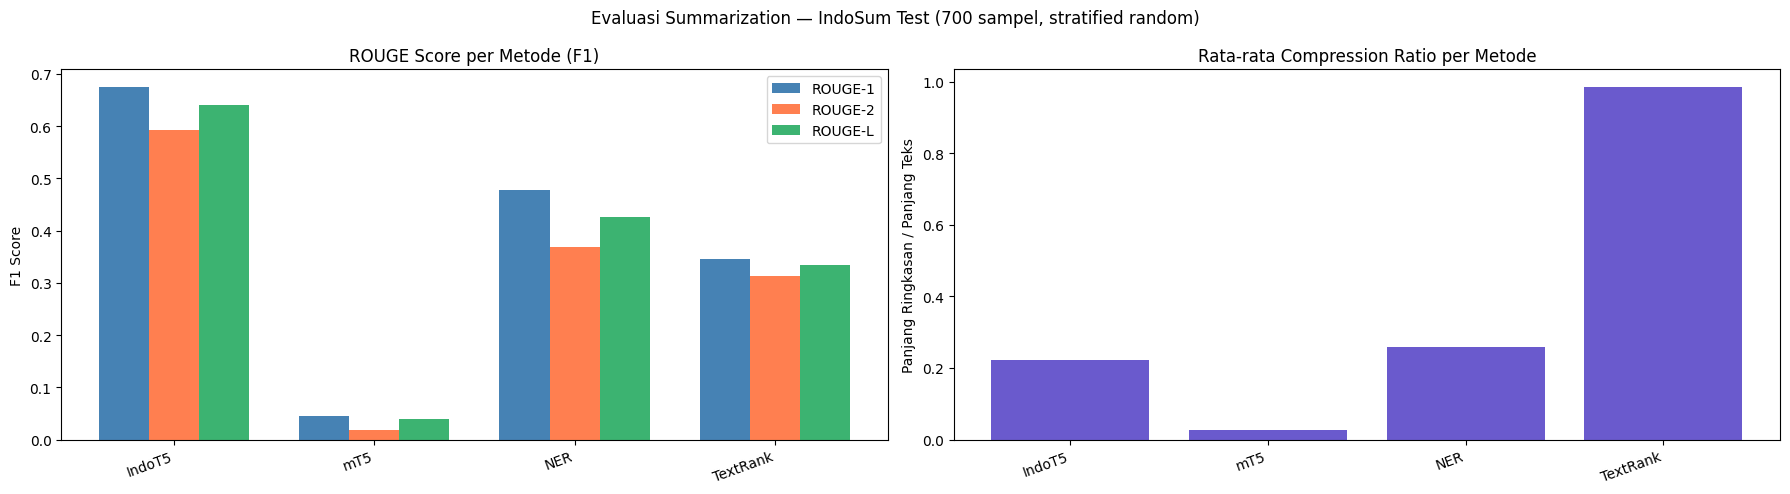


Ringkasan Numerik:
          ROUGE-1  ROUGE-2  ROUGE-L  Compression Ratio
IndoT5     0.6748   0.5931   0.6397             0.2214
mT5        0.0451   0.0175   0.0402             0.0276
NER        0.4778   0.3692   0.4262             0.2579
TextRank   0.3453   0.3135   0.3340             0.9851


In [40]:
# Visualisasi: ROUGE score dan compression ratio
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 5))

x      = range(len(results_df))
width  = 0.25
colors = ["steelblue", "coral", "mediumseagreen"]

for i, metric in enumerate(["ROUGE-1", "ROUGE-2", "ROUGE-L"]):
    ax1.bar([xi + i * width for xi in x], results_df[metric], width,
            label=metric, color=colors[i])
ax1.set_xticks([xi + width for xi in x])
ax1.set_xticklabels(results_df.index, rotation=20, ha="right")
ax1.set_title("ROUGE Score per Metode (F1)")
ax1.set_ylabel("F1 Score")
ax1.legend()

ax2.bar(results_df.index, results_df["Compression Ratio"], color="slateblue")
ax2.set_title("Rata-rata Compression Ratio per Metode")
ax2.set_ylabel("Panjang Ringkasan / Panjang Teks")
ax2.tick_params(axis='x', rotation=20)
for tick in ax2.get_xticklabels():
    tick.set_ha("right")

plt.suptitle(f"Evaluasi Summarization — IndoSum Test ({N_TEST} sampel, stratified random)")
plt.tight_layout()
plt.show()

print("\nRingkasan Numerik:")
print(results_df.to_string())

In [41]:
# Perbandingan output side-by-side pada satu sampel
print("=" * 70)
print("Perbandingan Output — Sampel Pertama")
print("=" * 70)
print()
print("TEKS ASLI (200 karakter pertama):")
print(test_subset[0]["text"][:200])
print()
print("REFERENSI:")
print(test_subset[0]["summary"])
print()
for name, preds in all_methods:
    print(f"{name}:")
    print(preds[0][:200] if preds and preds[0] else "(kosong)")
    print()

Perbandingan Output — Sampel Pertama

TEKS ASLI (200 karakter pertama):
ITALIA– AS Roma berhasil mencuri tiga angka dari kandang Udinese dalam lanjutan Serie A Liga Italia , Sabtu 917 / 2 / 2018 ) malam WIB .. Meski dengan susah payah Roma mampu unggul 2 - 0 lewat gol Und

REFERENSI:
AS Roma berhasil mencuri tiga angka dari kandang Udinese dalam lanjutan Serie A Liga Italia , Sabtu 917 / 2 / 2018 ) malam WIB . Meski dengan susah payah Roma mampu unggul 2 - 0 lewat gol Cengiz Under ( 70 ) dan Perotti ( 90 ) . Kemenangan ini membawa AS Roma sementara naik ke posisi ketiga dengan nilai 50 dari 25 kali laga menggusur Inter Milan ke posisi keempat .

IndoT5:
AS Roma berhasil mencuri tiga angka dari kandang Udinese dalam lanjutan Serie A Liga Italia , Sabtu 917 / 2 / 2018 . Kemenangan ini tentu sangat berarti untuk Serigala Ibukota julukan Roma karena mere

mT5:
<extra_id_0> , namun gagal ..

NER:
ITALIA– AS Roma berhasil mencuri tiga angka dari kandang Udinese dalam lanjutan Serie A Liga It

# ZIP Code di kaggle


In [42]:
import shutil
from pathlib import Path

zip_dir  = Path('/kaggle/working') if IN_KAGGLE else OUTPUT_DIR
zip_path = str(zip_dir / 'all_models')

print('Membuat zip seluruh model...')
shutil.make_archive(zip_path, 'zip', str(MODEL_DIR.parent), MODEL_DIR.name)

size_mb = (zip_dir / 'all_models.zip').stat().st_size / 1024 / 1024
print(f'all_models.zip  →  {size_mb:.1f} MB')
print()
if IN_KAGGLE:
    print('Download: tab Output → all_models.zip → Download')
print('Ekstrak ke Project_Summarize_NLP/model/ untuk inference lokal.')


Membuat zip seluruh model...
all_models.zip  →  4576.5 MB

Download: tab Output → all_models.zip → Download
Ekstrak ke Project_Summarize_NLP/model/ untuk inference lokal.


# Inference coba


In [44]:
# Inference
INPUT_TEXT = """
Badan Gizi Nasional (BGN) mengancam sanksi penghentian sementara operasional dapur Makan Bergizi Gratis (MBG) bagi Satuan Pelayanan Pemenuhan Gizi (SPPG) yang tidak memprioritaskan kelompok rentan, yakni ibu hamil, ibu menyusui, dan balita.
Lewat Surat Edaran Nomor 5 Tahun 2026 yang dirilis Kedeputian Bidang Pemantauan dan Pengawasan (Tauwas) BGN, setiap dapur SPPG kini diwajibkan melayani minimal 300 penerima manfaat dari kelompok 3B, yakni ibu hamil, ibu menyusui, dan balita.
Deputi Tauwas BGN Dadang Hendrayuda mengatakan aturan tersebut dibuat untuk memastikan kelompok paling rentan benar-benar mendapatkan akses program MBG.
"Surat Edaran ini kami keluarkan untuk menjamin cakupan pelayanan gizi bagi kelompok 3B, dan meningkatkan konsistensi pelaksanaan SPPG di seluruh wilayah," kata Dadang mengutip detikcom, Senin (25/5).
Dadang mengungkapkan pihaknya masih menemukan banyak dapur MBG yang belum memenuhi target penerima manfaat dari kelompok 3B.
Padahal sebelumnya BGN sudah menetapkan target pelayanan hingga 500 penerima manfaat untuk ibu hamil, ibu menyusui, dan balita.
"Saat sidak di lapangan kami sering menemukan SPPG yang hanya melayani kurang dari 100 penerima manfaat 3B," ujarnya.
Lewar aturan terbaru ini, BGN menetapkan batas minimal baru yakni 300 penerima manfaat kelompok 3B di setiap SPPG.
Selain itu, BGN memastikan akan menjatuhkan sanksi administratif bagi pihak yang tidak memenuhi ketentuan tersebut.
Sementara bagi mitra maupun yayasan pengelola SPPG, sanksinya lebih berat. Dapur MBG yang tidak memenuhi kewajiban minimal pelayanan 3B akan dikenai suspend kategori major.
"Karena sanksi yang dikenakan kepada mereka adalah suspend mayor, maka mereka tidak mendapatkan insentif Rp 6 juta per hari sampai pemenuhan ketentuan dapat dibuktikan," kata Dadang.
Berlaku 2 Juni 2026
Untuk pengawasan, Kepala SPPG diwajibkan menyampaikan laporan capaian pelayanan kelompok 3B secara berkala kepada Direktorat Wilayah Deputi Tauwas.
Laporan tersebut nantinya akan diverifikasi dan menjadi dasar penilaian kepatuhan setiap dapur MBG.
Meski begitu, Dadang menyebut pengelola tetap diberi kesempatan melakukan klarifikasi sesuai prosedur administratif BGN sebelum sanksi dijatuhkan.
"Tapi yang jelas, aturan tentang pelayanan minimal 300 penerima manfaat dari kelompok 3B ini wajib dilaksanakan mulai tanggal 2 Juni 2026," tegas purnawirawan jenderal Kopassus tersebut.
BGN menilai kelompok ibu hamil, ibu menyusui, dan balita menjadi prioritas karena termasuk kelompok paling rentan mengalami masalah gizi dan stunting.
""".strip()
APPLY_DIALECT = False

print(f'Input ({len(INPUT_TEXT.split())} kata):')
print(INPUT_TEXT[:200])
print()

# Textrank
tr_input = preprocess_extractive(INPUT_TEXT, apply_dialect=APPLY_DIALECT)
tr_out   = summarize_textrank(tr_input, n_sentences=2)
print(f'[TextRank]\n  {tr_out}\n')

# NER
try:
    _ner_inf = pipeline('ner', model=NER_PATH,
                        aggregation_strategy='simple',
                        device=0 if DEVICE == 'cuda' else -1)
    ner_out  = ner_summarize(INPUT_TEXT, _ner_inf, n_sentences=2)
    print(f'[NER]\n  {ner_out}\n')
    del _ner_inf
except Exception as e:
    print(f'[NER] Gagal load: {e}\n')

# IndoT5
try:
    _it_tok = AutoTokenizer.from_pretrained(INDOT5_PATH)
    _it_mdl = AutoModelForSeq2SeqLM.from_pretrained(INDOT5_PATH).to(DEVICE)
    _it_mdl.eval()
    _inp    = _it_tok(preprocess_abstractive(INPUT_TEXT, APPLY_DIALECT),
                      return_tensors='pt', max_length=MAX_INPUT_LEN,
                      truncation=True).to(DEVICE)
    with torch.no_grad():
        _out = _it_mdl.generate(**_inp, max_new_tokens=MAX_TARGET_LEN, num_beams=4)
    print(f'[IndoT5]\n  {_it_tok.decode(_out[0], skip_special_tokens=True)}\n')
    del _it_mdl; gc.collect()
    if DEVICE == 'cuda': torch.cuda.empty_cache()
except Exception as e:
    print(f'[IndoT5] Gagal load: {e}\n')

# MT5
try:
    _m5_tok = AutoTokenizer.from_pretrained(MT5_PATH)
    _m5_mdl = AutoModelForSeq2SeqLM.from_pretrained(MT5_PATH).to(DEVICE)
    _m5_mdl.eval()
    _inp    = _m5_tok('summarize: ' + preprocess_abstractive(INPUT_TEXT, APPLY_DIALECT),
                      return_tensors='pt', max_length=MAX_INPUT_LEN,
                      truncation=True).to(DEVICE)
    with torch.no_grad():
        _out = _m5_mdl.generate(**_inp, max_new_tokens=MAX_TARGET_LEN, num_beams=4,
                                decoder_start_token_id=_m5_tok.pad_token_id)
    print(f'[mT5]\n  {_m5_tok.decode(_out[0], skip_special_tokens=True)}\n')
    del _m5_mdl; gc.collect()
    if DEVICE == 'cuda': torch.cuda.empty_cache()
except Exception as e:
    print(f'[mT5] Gagal load: {e}\n')


Input (349 kata):
Badan Gizi Nasional (BGN) mengancam sanksi penghentian sementara operasional dapur Makan Bergizi Gratis (MBG) bagi Satuan Pelayanan Pemenuhan Gizi (SPPG) yang tidak memprioritaskan kelompok rentan, ya

[TextRank]
  badan gizi nasional (bgn) mengancam sanksi penghentian sementara operasional dapur makan bergizi gratis (mbg) bagi satuan pelayanan pemenuhan gizi (sppg) yang tidak memprioritaskan kelompok rentan, yakni ibu hamil, ibu menyusui, dan balita.. lewat surat edaran nomor 5 tahun 2026 yang dirilis kedeputian bidang pemantauan dan pengawasan (tauwas) bgn, setiap dapur sppg kini diwajibkan melayani minimal 300 penerima manfaat dari kelompok 3b, yakni ibu hamil, ibu menyusui, dan balita.. deputi tauwas bgn dadang hendrayuda mengatakan aturan tersebut dibuat untuk memastikan kelompok paling rentan benar-benar mendapatkan akses program mbg.. "surat edaran ini kami keluarkan untuk menjamin cakupan pelayanan gizi bagi kelompok 3b, dan meningkatkan konsistensi pelaksanaa

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[NER]
  Badan Gizi Nasional (BGN) mengancam sanksi penghentian sementara operasional dapur Makan Bergizi Gratis (MBG) bagi Satuan Pelayanan Pemenuhan Gizi (SPPG) yang tidak memprioritaskan kelompok rentan, yakni ibu hamil, ibu menyusui, dan balita. Lewat Surat Edaran Nomor 5 Tahun 2026 yang dirilis Kedeputian Bidang Pemantauan dan Pengawasan (Tauwas) BGN, setiap dapur SPPG kini diwajibkan melayani minimal 300 penerima manfaat dari kelompok 3B, yakni ibu hamil, ibu menyusui, dan balita



Loading weights:   0%|          | 0/257 [00:00<?, ?it/s]

[IndoT5]
  Badan gizi nasional ( bgn) mengancam sanksi penghentian sementara operasional dapur makan bergizi gratis (mbg) bagi satuan pelayanan pemenuhan gizi (sppg) yang tidak memprioritaskan kelompok rentan, yakni ibu hamil , ibu menyusui , dan balita. Lewat surat edaran nomor 5 tahun 2026 yang dirilis kedeputian bidang pemantauan dan pengawasan (tauwas) bgn, setiap dapur sppg kini diwajibkan melayani minimal 300 penerima manfaat dari kelompok 3b, yakni ibu hamil , ibu menyusui , dan balita.



Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


[mT5]
  <extra_id_0>, sementara kepala sppg.

